In [4]:
import pandas as pd

# Load the dataset
df = pd.read_excel("/content/Marketing Data - Hiring.xlsx")

# 1. Dataset Cleaning & Familiarization
# Standardizing column names
df.columns = df.columns.str.strip()
df['Activity Date'] = pd.to_datetime(df['Activity Date'])
df['Month'] = df['Activity Date'].dt.to_period('M')

# Check 'Count of Activity Metrics' to see if it has data or is all null
# The snippet showed nulls, but we check if we should sum this column or count rows.
has_metrics_count = df['Count of Activity Metrics'].notna().sum() > 0

# Define logic for volume vs. engagement based on unique 'Activity' values
unique_activities = df['Activity'].unique()

# Assumption based on standard marketing data:
# 'Sent', 'Delivered' = Outreach (Counts toward Frequency)
# 'Open', 'Click', 'Downloaded', 'Replied' = Engagement
# We will inspect unique_activities to classify them accurately.

# 2. Metric Calculation Logic
def calculate_metrics(data):
    # Reach: Unique Physicians
    reach = data['Physician ID'].nunique()

    # Total Activities (Volume): Count of rows (or sum of metrics if valid)
    total_activities = len(data)

    # Frequency: Average number of times a physician was contacted
    frequency = total_activities / reach if reach > 0 else 0

    # Engagement: Interactions (excluding passive "Sent"/"Delivered" states)
    # We will refine the exclusion list after seeing the unique values
    passive_states = ['Sent', 'Delivered', 'Queued', 'Bounced', 'Dropped']
    engagement_count = data[~data['Activity'].isin(passive_states)].shape[0]

    return pd.Series({
        'Reach': reach,
        'Total_Activities': total_activities,
        'Frequency': round(frequency, 2),
        'Engagement_Count': engagement_count,
        'Engagement_Rate': round((engagement_count / total_activities) * 100, 2) if total_activities > 0 else 0
    })

# 3. Execution
# Get unique activities to confirm classification
activities_list = df['Activity'].unique()

# Overall Metrics
overall_metrics = calculate_metrics(df)

# Segmentation: Source, Channel, Month
segmentation = df.groupby(['Communication Source', 'Source Channel Name', 'Month']).apply(calculate_metrics, include_groups=False).reset_index()

# Sort segmentation for insights (e.g., by Engagement Count)
top_segments = segmentation.sort_values(by='Engagement_Count', ascending=False).head(10)

# Display results for report generation
print("Unique Activities found:", activities_list)
print("\n--- Overall Metrics ---")
print(overall_metrics)
print("\n--- Top Segments (Sample) ---")
print(top_segments)

Unique Activities found: ['Sent' 'Delivered' 'Open' 'Bounce' 'Click' 'Unsubscribe' 'Hard Bounce']

--- Overall Metrics ---
Reach                25208.00
Total_Activities    100040.00
Frequency                3.97
Engagement_Count     23181.00
Engagement_Rate         23.17
dtype: float64

--- Top Segments (Sample) ---
  Communication Source Source Channel Name    Month    Reach  \
2    Internal CRM Tool               Email  2024-03  11586.0   
7     Remission Report               Email  2024-01   3133.0   
1    Internal CRM Tool               Email  2024-02   9357.0   
3          Medspace360         Email Alert  2024-01   7388.0   
0    Internal CRM Tool               Email  2024-01  10107.0   
8           Sales Reps               Email  2024-01   7420.0   
6            Oncopulse                 SMS  2024-03   1146.0   
4            Oncopulse                 SMS  2024-01    712.0   
5            Oncopulse                 SMS  2024-02    928.0   

   Total_Activities  Frequency  Engageme

In [8]:
df.head()

,Communication Source,Source Channel Name,Therapeutic Area,Device,Source Device Name,Activity,Count of Activity Metrics,Activity Date,Physician ID,Month
0,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-01-24,3049662215,2024-01
1,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-02-12,3049662215,2024-02
2,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-03-01,3049662215,2024-03
3,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-03-05,3049662215,2024-03
4,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-03-05,3049662215,2024-03


/tmp/ipython-input-3879624230.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_metrics = df.groupby('Communication Source').apply(calculate_metrics).reset_index()


  Communication Source    Reach  Total_Activities  Frequency  \
0    Internal CRM Tool  12647.0           71773.0       5.68   
3     Remission Report   3133.0            4803.0       1.53   
2            Oncopulse   1848.0            4923.0       2.66   
1          Medspace360   7388.0            9797.0       1.33   
4           Sales Reps   7420.0            8744.0       1.18   

   Engagement_Count  Engagement_Rate  
0           12168.0            16.95  
3            4803.0           100.00  
2            2467.0            50.11  
1            2409.0            24.59  
4            1334.0            15.26  


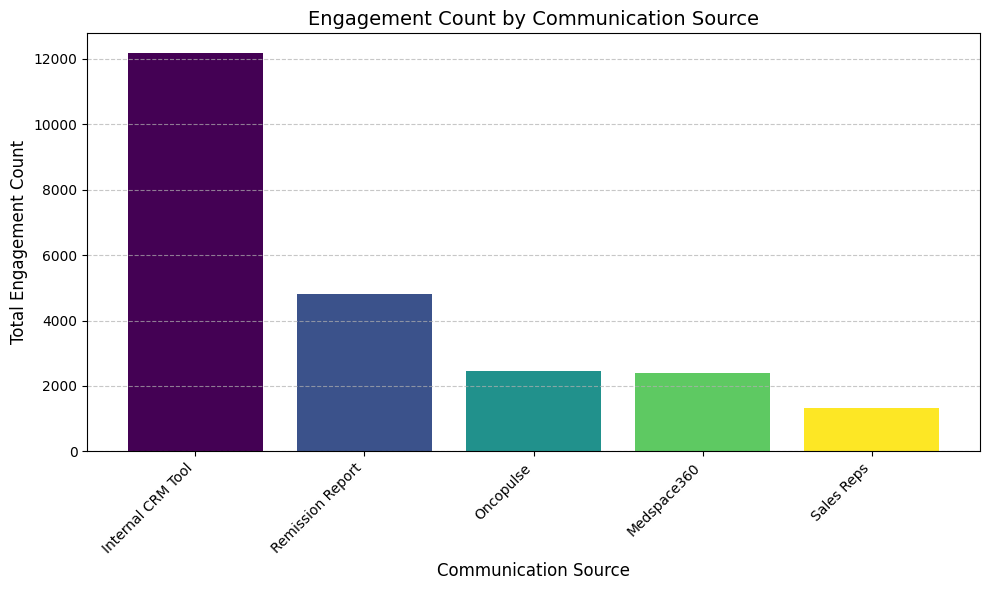

In [13]:
import matplotlib.pyplot as plt
import numpy as np
# Calculate metrics segmented by Communication Source
source_metrics = df.groupby('Communication Source').apply(calculate_metrics).reset_index()

# Sort the data by Engagement_Count
source_metrics_sorted = source_metrics.sort_values(by='Engagement_Count', ascending=False)

# Generate the bar chart
plt.figure(figsize=(10, 6))

# Use the sorted data for plotting
plt.bar(
    source_metrics_sorted['Communication Source'],
    source_metrics_sorted['Engagement_Count'],
    color=plt.cm.viridis(np.linspace(0, 1, len(source_metrics_sorted)))
)

plt.title('Engagement Count by Communication Source', fontsize=14)
plt.xlabel('Communication Source', fontsize=12)
plt.ylabel('Total Engagement Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig('Engagement_by_Source_Bar_Chart.png')

# Display the underlying data
print(source_metrics_sorted)